# CPS Industry Employment (2018–2024) — XGBoost vs ARIMA


- **XGBoost** using features: `lag1, lag2, yoy_pct, two_year_change`
- **ARIMA** univariate (per industry)

It evaluates each model by predicting **2024** from past years (train up to 2023), per industry, then compares metrics.


In [1]:
# 1) Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    print("WARNING: xgboost is not available. Install with: pip install xgboost")
    XGB_AVAILABLE = False

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

pd.set_option("display.max_colwidth", 140)

In [3]:
# 2) Load data
CSV_PATH = "cps_combined_2018_2024_long.csv"
raw = pd.read_csv(CSV_PATH)
raw.shape, raw.dtypes

((68362, 6),
 SourceTable     object
 Year             int64
 RowLabel        object
 Metric          object
 Value          float64
 SourceFile      object
 dtype: object)

In [4]:
# 3) ***Same preprocessing as in your EDA***
# Filter to years 2018–2024 and normalize 'Metric'
df = raw[raw["Year"].between(2018, 2024)].copy()
df["Metric_clean"] = df["Metric"].str.replace(r"^\s*(19|20)\d{2}\s+", "", regex=True).str.strip()
mask_notes = df["Metric_clean"].str.startswith(("NOTE", "Footnotes"), na=False)
df = df[~mask_notes].copy()

# Industry sector mask
sector_keywords = [
    'Agriculture', 'Mining', 'Utilities', 'Construction', 'Manufacturing',
    'Wholesale', 'Retail', 'Transportation', 'Warehousing',
    'Information', 'Financial', 'Professional', 'Business',
    'Education', 'Health', 'Leisure', 'Hospitality', 'Government',
    'Public administration', 'Other services'
]
mask_sector = df["RowLabel"].str.contains("|".join(sector_keywords), case=False, na=False)

# Focus on Total employed by industry
df_emp = df[mask_sector & (df["Metric_clean"].str.fullmatch("Total employed", na=False))].copy()
df_emp = df_emp.dropna(subset=["Value"])

# Derive 'Industry' and clean
df_emp["Industry"] = df_emp["RowLabel"].str.replace(r"\s{2,}", " ", regex=True).str.strip()
bad_industry_tokens = ("Total,", "Total ", "TOTAL", "Men,", "Women,", "years", "Hispanic", "White", "Black", "Asian")
df_emp = df_emp[~df_emp["Industry"].str.startswith(bad_industry_tokens, na=False)].copy()

# Aggregate to yearly industry employment
emp_agg = (
    df_emp.groupby(["Year", "Industry"], as_index=False)["Value"]
        .mean()
        .rename(columns={"Value": "Employed_thousands"})
)

emp_agg.head(10)

,Year,Industry,Employed_thousands
0,2018,Aerospace product and parts manufacturing,51.000000
1,2018,Agricultural chemical manufacturing,37.000000
2,2018,Agricultural implement manufacturing,114.000000
3,2018,Agriculture and related,1200.333333
4,2018,"Agriculture, forestry, fishing, and hunting",2425.000000
5,2018,Air transportation,635.000000
6,2018,Aircraft and parts manufacturing,805.000000
7,2018,Alcoholic beverages merchant wholesalers,115.000000
8,2018,Apparel accessories and other apparel manufacturing,11.000000
9,2018,"Apparel, piece goods, and notions merchant wholesalers",95.000000


In [5]:
# 4) EXACT same lag features as in EDA
panel = emp_agg.sort_values(["Industry", "Year"]).copy()
panel["lag1"] = panel.groupby("Industry")["Employed_thousands"].shift(1)
panel["lag2"] = panel.groupby("Industry")["Employed_thousands"].shift(2)
panel["yoy_pct"] = (panel["Employed_thousands"] - panel["lag1"]) / panel["lag1"] * 100
panel["two_year_change"] = (panel["Employed_thousands"] - panel["lag2"]) / panel["lag2"] * 100
panel["target_next_year"] = panel.groupby("Industry")["Employed_thousands"].shift(-1)

train_ready = panel.dropna(subset=["lag1", "lag2", "target_next_year"]).reset_index(drop=True)
print(train_ready[["Year","Industry","Employed_thousands","lag1","lag2","yoy_pct","two_year_change","target_next_year"]].head(8))

   Year                                    Industry  Employed_thousands  lag1  \
0  2022  Aerospace products and parts manufacturing                77.0  84.0   
1  2023  Aerospace products and parts manufacturing                44.0  77.0   
2  2020         Agricultural chemical manufacturing                35.0  37.0   
3  2021         Agricultural chemical manufacturing                32.0  35.0   
4  2022         Agricultural chemical manufacturing                27.0  32.0   
5  2023         Agricultural chemical manufacturing                33.0  27.0   
6  2020        Agricultural implement manufacturing                93.0  97.0   
7  2021        Agricultural implement manufacturing               130.0  93.0   

    lag2    yoy_pct  two_year_change  target_next_year  
0   44.0  -8.333333        75.000000              44.0  
1   84.0 -42.857143       -47.619048              46.0  
2   37.0  -5.405405        -5.405405              32.0  
3   37.0  -8.571429       -13.513514      

## Evaluation protocol
For each industry:
- **XGBoost**: Train on rows up to **2023** (features from that row), predict **next year** (i.e., 2024).  
- **ARIMA**: Fit on the **time series up to 2023**, forecast **1 step** to 2024.  
We then compute errors against the actual 2024 value and aggregate results.


In [6]:
# 5) Helpers
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100

def evaluate(y_true, y_pred):
    return {
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }

In [7]:
# 6) Slice train rows ending at 2023 (to predict 2024)
# Keep only rows whose target_next_year is 2024 so evaluation is consistent
last_year = 2024
eval_rows = train_ready[train_ready["Year"] == last_year - 1].copy()  # 2023 rows with a 2024 target

features = ["lag1","lag2","yoy_pct","two_year_change"]
print("Industries with a 2024 target:", eval_rows["Industry"].nunique())

Industries with a 2024 target: 144


In [16]:
# 7) Rolling-origin evaluation years: predict each year t in 2020..2024 from history up to t-1
test_years = [2020, 2021, 2022, 2023, 2024]
features = ["lag1", "lag2", "yoy_pct", "two_year_change"]

def safe_clip_nonneg(a):
    # guard against tiny negatives after inverse transforms
    return np.maximum(a, 0.0)


In [17]:
# 8) XGBoost rolling backtest per industry (predict 1-step ahead for each test year)
xgb_rows = []

if XGB_AVAILABLE:
    for ind, grp in train_ready.groupby("Industry", sort=False):
        g = grp.sort_values("Year").copy()
        for t in test_years:
            # to evaluate year t, we need the row at (t-1) as features with target_next_year == t
            row_te = g[g["Year"] == t-1].dropna(subset=features + ["target_next_year"])
            trn = g[g["Year"] < t-1].dropna(subset=features + ["target_next_year"])
            if len(row_te) == 1 and len(trn) >= 1:
                X_tr = trn[features].values
                y_tr = trn["target_next_year"].values
                X_te = row_te[features].values
                y_te = row_te["target_next_year"].values

                model = XGBRegressor(
                    n_estimators=400, max_depth=3, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, random_state=42
                )
                model.fit(X_tr, y_tr)
                yhat = float(model.predict(X_te)[0])
                xgb_rows.append({
                    "Industry": ind,
                    "year_pred": t,
                    "y_true": float(y_te[0]),
                    "y_pred": safe_clip_nonneg(yhat)
                })
else:
    print("Skipping XGBoost — xgboost package not available.")

df_xgb = pd.DataFrame(xgb_rows)
print("XGB predictions:", df_xgb.shape, "years covered:", sorted(df_xgb['year_pred'].unique()) if len(df_xgb) else [])
display(df_xgb.head(10))


XGB predictions: (403, 4) years covered: [np.int64(2022), np.int64(2023), np.int64(2024)]


,Industry,year_pred,y_true,y_pred
0,Aerospace products and parts manufacturing,2024,46.000000,44.000000
1,Agricultural chemical manufacturing,2022,27.000000,32.000000
2,Agricultural chemical manufacturing,2023,33.000000,27.000977
3,Agricultural chemical manufacturing,2024,44.000000,33.248550
4,Agricultural implement manufacturing,2022,133.000000,130.000000
5,Agricultural implement manufacturing,2023,148.000000,130.527252
6,Agricultural implement manufacturing,2024,118.000000,144.811554
7,Agriculture and related,2022,1130.500000,1131.000000
8,Agriculture and related,2023,1119.500000,1130.502441
9,Agriculture and related,2024,1113.833333,1119.502441


In [24]:
# 9) ARIMA rolling backtest per industry — robust & bounded
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX

def safe_clip_nonneg(a):  # keep from previous cells if already defined
    return np.maximum(a, 0.0)

def bounds_from_history(y, factor=3.0):
    y = np.asarray(y, dtype=float)
    hi = max(1.0, np.nanmax(y)) * factor
    return 0.0, hi

# keep the search tiny for short yearly series
CANDIDATE_ORDERS = [(1,1,0), (0,1,1), (1,1,1), (2,1,0), (0,1,2)]

def best_order_log1p(y_log):
    best_aic, best = np.inf, None
    for (p,d,q) in CANDIDATE_ORDERS:
        try:
            res = SARIMAX(
                y_log,
                order=(p,d,q),
                enforce_stationarity=True,
                enforce_invertibility=True,
                simple_differencing=True,
            ).fit(disp=False, maxiter=200)
            if res.aic < best_aic:
                best_aic, best = res.aic, (p,d,q)
        except Exception:
            continue
    return best

def arima_1step_log_robust(y_hist):
    # stabilize
    y_hist = np.asarray(y_hist, dtype=float)
    lo, hi = bounds_from_history(y_hist, factor=3.0)
    y_log = np.log1p(np.clip(y_hist, a_min=0.0, a_max=None))

    order = best_order_log1p(y_log)
    if order is None:
        return None, None

    res = SARIMAX(
        y_log,
        order=order,
        enforce_stationarity=True,
        enforce_invertibility=True,
        simple_differencing=True,
    ).fit(disp=False, maxiter=200)

    yhat_log = float(res.get_forecast(steps=1).predicted_mean[-1])
    yhat = np.expm1(yhat_log)
    # clip to reasonable domain
    yhat = float(np.clip(yhat, lo, hi))
    return yhat, order

arima_rows = []
for ind, grp in emp_agg.groupby("Industry", sort=False):
    g = grp.sort_values("Year")
    for t in test_years:  # e.g., 2020..2024
        hist = g[g["Year"] <= t-1]["Employed_thousands"].values
        truth = g[g["Year"] == t]["Employed_thousands"].values
        if len(hist) >= 3 and len(truth) == 1:
            yhat, order = arima_1step_log_robust(hist)
            if yhat is None:
                continue
            arima_rows.append({
                "Industry": ind,
                "year_pred": t,
                "y_true": float(truth[0]),
                "y_pred": safe_clip_nonneg(yhat),
                "order": order
            })

df_arima = pd.DataFrame(arima_rows)
print("ARIMA predictions:", df_arima.shape, "years:", sorted(df_arima['year_pred'].unique()) if len(df_arima) else [])
display(df_arima.head(10))


ARIMA predictions: (550, 5) years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,Industry,year_pred,y_true,y_pred,order
0,Agricultural chemical manufacturing,2021,32.0,0.000000,"(1, 1, 0)"
1,Agricultural chemical manufacturing,2022,27.0,0.000000,"(2, 1, 0)"
2,Agricultural chemical manufacturing,2023,33.0,0.000000,"(1, 1, 0)"
3,Agricultural chemical manufacturing,2024,44.0,0.000000,"(0, 1, 1)"
4,Agricultural implement manufacturing,2021,130.0,0.000000,"(1, 1, 0)"
5,Agricultural implement manufacturing,2022,133.0,0.000000,"(0, 1, 1)"
6,Agricultural implement manufacturing,2023,148.0,0.000178,"(0, 1, 1)"
7,Agricultural implement manufacturing,2024,118.0,0.002752,"(0, 1, 1)"
8,Agriculture and related,2021,1131.0,0.000000,"(1, 1, 0)"
9,Agriculture and related,2022,1130.5,0.013323,"(2, 1, 0)"


In [25]:
# 9) Normalize column names BEFORE merge, then merge on (Industry, year_pred)

# Guard: make sure frames exist
if 'df_xgb' not in globals():
    df_xgb = pd.DataFrame(columns=['Industry','year_pred','y_true','y_pred'])
if 'df_arima' not in globals():
    df_arima = pd.DataFrame(columns=['Industry','year_pred','y_true','y_pred'])

# Explicit renames (avoid pandas suffix surprises)
xgb_renamed = df_xgb.rename(columns={
    'y_true': 'y_true_xgb',
    'y_pred': 'y_pred_xgb'
})[['Industry','year_pred','y_true_xgb','y_pred_xgb']]

arima_cols = ['Industry','year_pred','y_true','y_pred'] + ([ 'order' ] if 'order' in df_arima.columns else [])
arima_renamed = df_arima[arima_cols].rename(columns={
    'y_true': 'y_true_arima',
    'y_pred': 'y_pred_arima'
})

both = pd.merge(xgb_renamed, arima_renamed, on=['Industry','year_pred'], how='inner')

print("both.shape:", both.shape)
print("both columns:", list(both.columns))
display(both.head(10))


both.shape: (403, 7)
both columns: ['Industry', 'year_pred', 'y_true_xgb', 'y_pred_xgb', 'y_true_arima', 'y_pred_arima', 'order']


,Industry,year_pred,y_true_xgb,y_pred_xgb,y_true_arima,y_pred_arima,order
0,Aerospace products and parts manufacturing,2024,46.000000,44.000000,46.000000,0.888924,"(2, 1, 0)"
1,Agricultural chemical manufacturing,2022,27.000000,32.000000,27.000000,0.000000,"(2, 1, 0)"
2,Agricultural chemical manufacturing,2023,33.000000,27.000977,33.000000,0.000000,"(1, 1, 0)"
3,Agricultural chemical manufacturing,2024,44.000000,33.248550,44.000000,0.000000,"(0, 1, 1)"
4,Agricultural implement manufacturing,2022,133.000000,130.000000,133.000000,0.000000,"(0, 1, 1)"
5,Agricultural implement manufacturing,2023,148.000000,130.527252,148.000000,0.000178,"(0, 1, 1)"
6,Agricultural implement manufacturing,2024,118.000000,144.811554,118.000000,0.002752,"(0, 1, 1)"
7,Agriculture and related,2022,1130.500000,1131.000000,1130.500000,0.013323,"(2, 1, 0)"
8,Agriculture and related,2023,1119.500000,1130.502441,1119.500000,0.023620,"(2, 1, 0)"
9,Agriculture and related,2024,1113.833333,1119.502441,1113.833333,0.000000,"(0, 1, 1)"


both.shape: (403, 7)
== OVERALL (pooled) ==
XGB  : {'RMSE': 153.29070857276093, 'MAE': 70.43714736736541, 'MAPE': np.float64(10.124102681169983)}
ARIMA: {'RMSE': 3865.2698989315963, 'MAE': 1715.8039966160636, 'MAPE': np.float64(99.92353199115622)}

== OVERALL (robust) ==
XGB  : {'MedAE': 21.00262451171875, 'P90AE': 195.31515625000065, 'MedAPE': 6.699629450618788}
ARIMA: {'MedAE': 320.0, 'P90AE': 6322.0495800755725, 'MedAPE': 100.0}

== YEAR-BY-YEAR (mean-based) ==


,year,Model,RMSE,MAE,MAPE
0,2022,XGB,148.704560,73.342638,10.877142
1,2022,ARIMA,3878.593066,1754.276876,99.878039
2,2023,XGB,143.730924,68.650871,8.784252
3,2023,ARIMA,3930.218533,1758.292031,99.948107
4,2024,XGB,165.374208,69.452489,10.672203
5,2024,ARIMA,3792.548004,1642.175088,99.942059


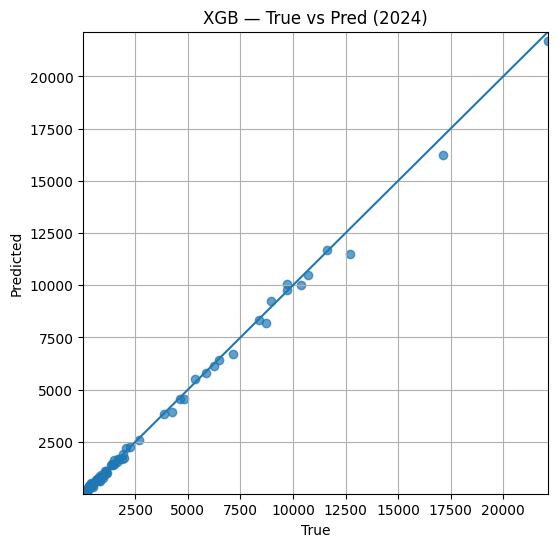

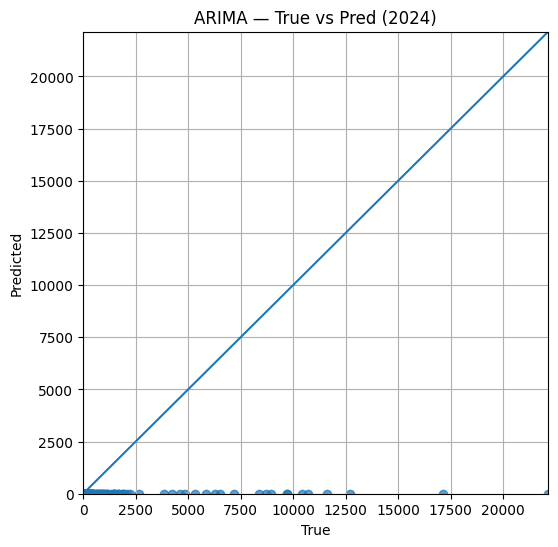

In [26]:
# 10) Metrics (mean + robust) and 2024 scatter plots

# Normalize column names first
xgb_renamed = df_xgb.rename(columns={'y_true':'y_true_xgb','y_pred':'y_pred_xgb'})[
    ['Industry','year_pred','y_true_xgb','y_pred_xgb']
]
arima_cols = ['Industry','year_pred','y_true','y_pred'] + (['order'] if 'order' in df_arima.columns else [])
arima_renamed = df_arima[arima_cols].rename(columns={'y_true':'y_true_arima','y_pred':'y_pred_arima'})

both = pd.merge(xgb_renamed, arima_renamed, on=['Industry','year_pred'], how='inner')
print("both.shape:", both.shape)

def evaluate_df(df, y_true_col, y_pred_col):
    return {
        "RMSE": sqrt(mean_squared_error(df[y_true_col], df[y_pred_col])),
        "MAE": mean_absolute_error(df[y_true_col], df[y_pred_col]),
        "MAPE": np.mean(np.minimum(np.abs((df[y_true_col]-df[y_pred_col]) / np.clip(np.abs(df[y_true_col]),1e-8,None))*100, 200.0))
    }

def robust_summary(df, y_true_col, y_pred_col):
    ae  = np.abs(df[y_true_col] - df[y_pred_col])
    ape = np.minimum(ae / np.clip(np.abs(df[y_true_col]),1e-8,None) * 100, 200.0)
    return {
        "MedAE": float(np.median(ae)),
        "P90AE": float(np.percentile(ae, 90)),
        "MedAPE": float(np.median(ape)),
    }

if len(both):
    print("== OVERALL (pooled) ==")
    overall_xgb   = evaluate_df(both, "y_true_xgb",   "y_pred_xgb")
    overall_arima = evaluate_df(both, "y_true_arima", "y_pred_arima")
    print("XGB  :", overall_xgb)
    print("ARIMA:", overall_arima)

    print("\n== OVERALL (robust) ==")
    print("XGB  :", robust_summary(both, "y_true_xgb",   "y_pred_xgb"))
    print("ARIMA:", robust_summary(both, "y_true_arima", "y_pred_arima"))

    # Year-by-year (mean-based)
    rows = []
    for y in sorted(both["year_pred"].unique()):
        bx = both[both["year_pred"] == y]
        rows.append({"year": y, "Model": "XGB",   **evaluate_df(bx, "y_true_xgb",   "y_pred_xgb")})
        rows.append({"year": y, "Model": "ARIMA", **evaluate_df(bx, "y_true_arima", "y_pred_arima")})
    yr_df = pd.DataFrame(rows)
    print("\n== YEAR-BY-YEAR (mean-based) ==")
    display(yr_df)

    # 2024 scatters
    def scatter_true_vs_pred(df, y_true_col, y_pred_col, title):
        plt.figure(figsize=(6,6))
        plt.scatter(df[y_true_col], df[y_pred_col], alpha=0.7)
        lims = [
            min(df[y_true_col].min(), df[y_pred_col].min()),
            max(df[y_true_col].max(), df[y_pred_col].max())
        ]
        plt.plot(lims, lims)
        plt.xlim(lims); plt.ylim(lims)
        plt.xlabel("True"); plt.ylabel("Predicted")
        plt.title(title); plt.grid(True); plt.show()

    bx_2024 = both[both["year_pred"] == 2024].copy()
    if len(bx_2024):
        scatter_true_vs_pred(bx_2024, "y_true_xgb",   "y_pred_xgb",   "XGB — True vs Pred (2024)")
        scatter_true_vs_pred(bx_2024, "y_true_arima", "y_pred_arima", "ARIMA — True vs Pred (2024)")
else:
    print("No overlapping rows to compare.")


,Industry,y2024_actual,xgb_2025,xgb_2026,xgb_grow_24_26_pct,arima_2025,arima_2026,arima_grow_24_26_pct
0,Aerospace products and parts manufacturing,46.000000,45.648342,45.648342,-0.764474,0.726012,0.244379,-99.468742
1,Agricultural chemical manufacturing,44.000000,35.055000,34.314018,-22.013595,0.070800,4.344341,-90.126497
2,Agricultural implement manufacturing,118.000000,118.002602,127.404182,7.969646,0.058422,0.000000,-100.000000
3,Agriculture and related,1113.833333,1113.835938,1113.835938,0.000234,0.003914,0.000000,-100.000000
4,"Agriculture, forestry, fishing, and hunting",2254.000000,2254.004883,2254.004883,0.000217,0.005743,0.000000,-100.000000
5,Air transportation,761.000000,653.391541,653.391541,-14.140402,0.006190,0.325916,-99.957173
6,Aircraft and parts manufacturing,938.000000,789.988098,789.988098,-15.779520,0.000000,0.000000,-100.000000
7,Alcoholic beverages merchant wholesalers,122.000000,111.370049,111.173859,-8.873886,0.000000,1.804090,-98.521238
8,"Apparel, piece goods, and notions merchant wholesalers",79.000000,87.246643,92.455284,17.032005,0.160408,0.000000,-100.000000
9,"Bakeries and tortilla manufacturing, except retail bakeries",162.000000,232.871552,218.887924,35.116003,0.253743,0.000000,-100.000000


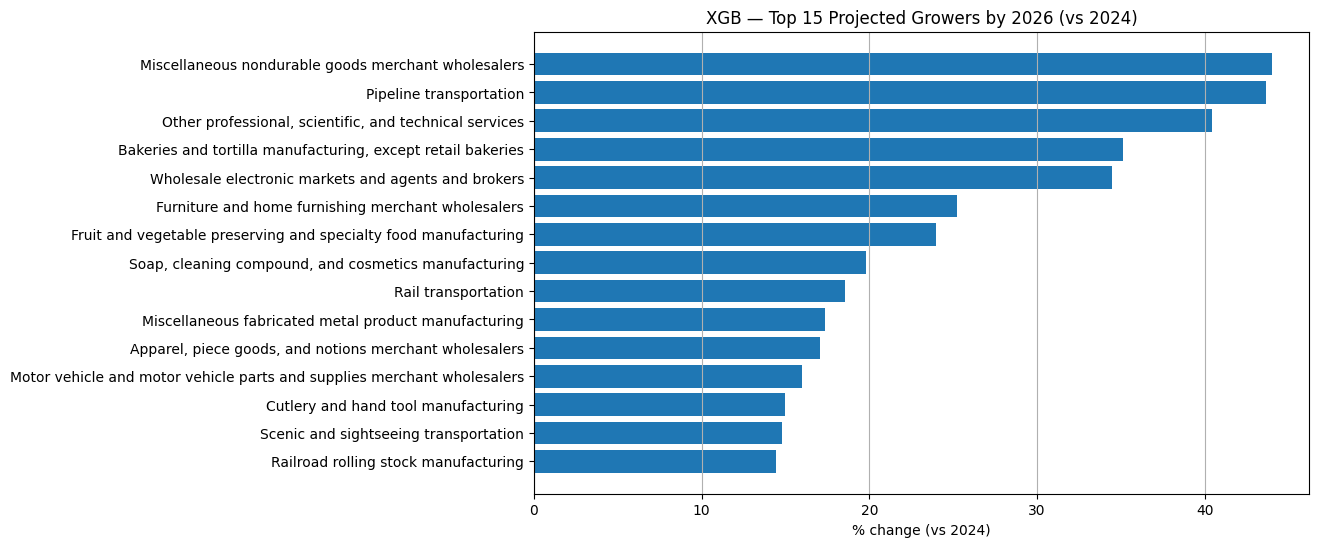

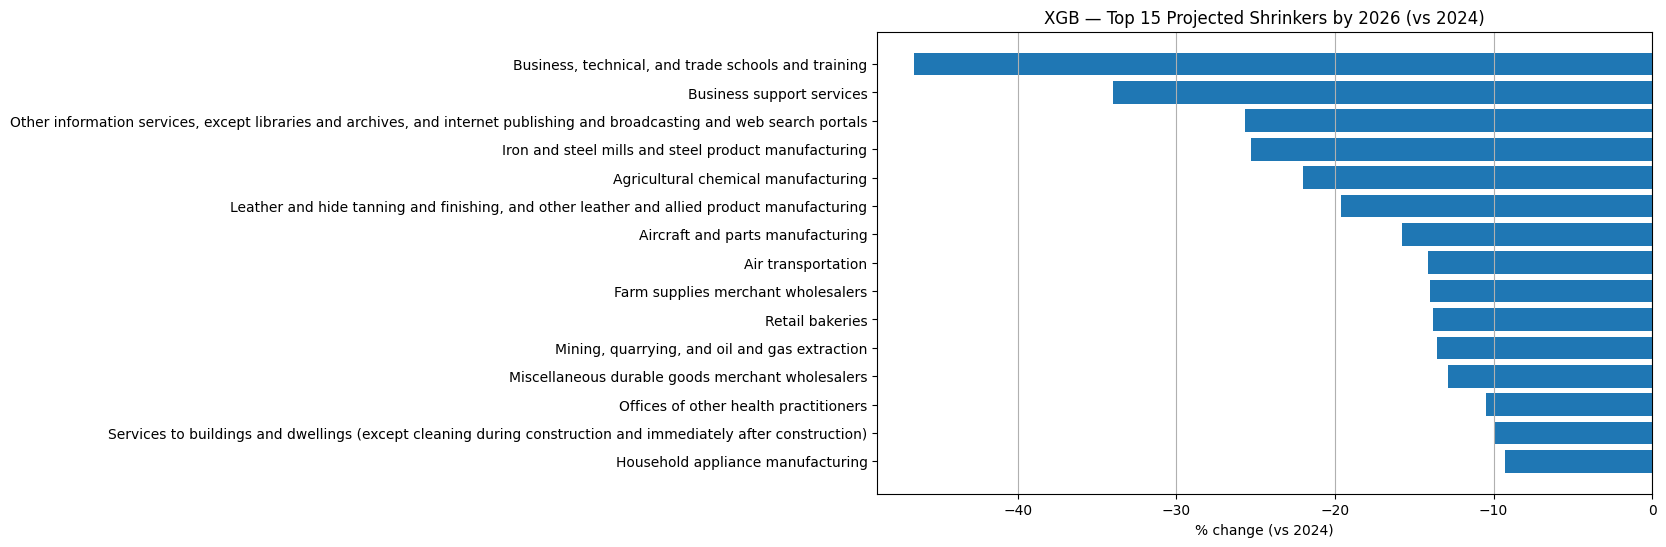

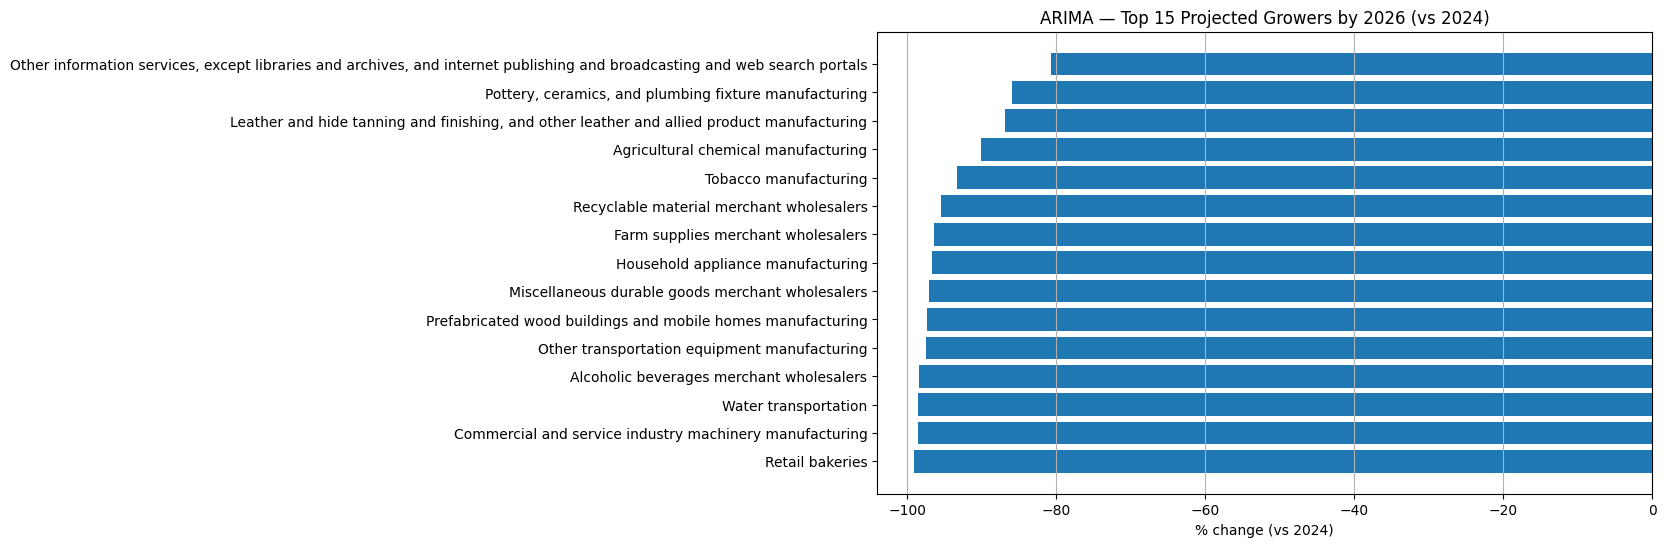

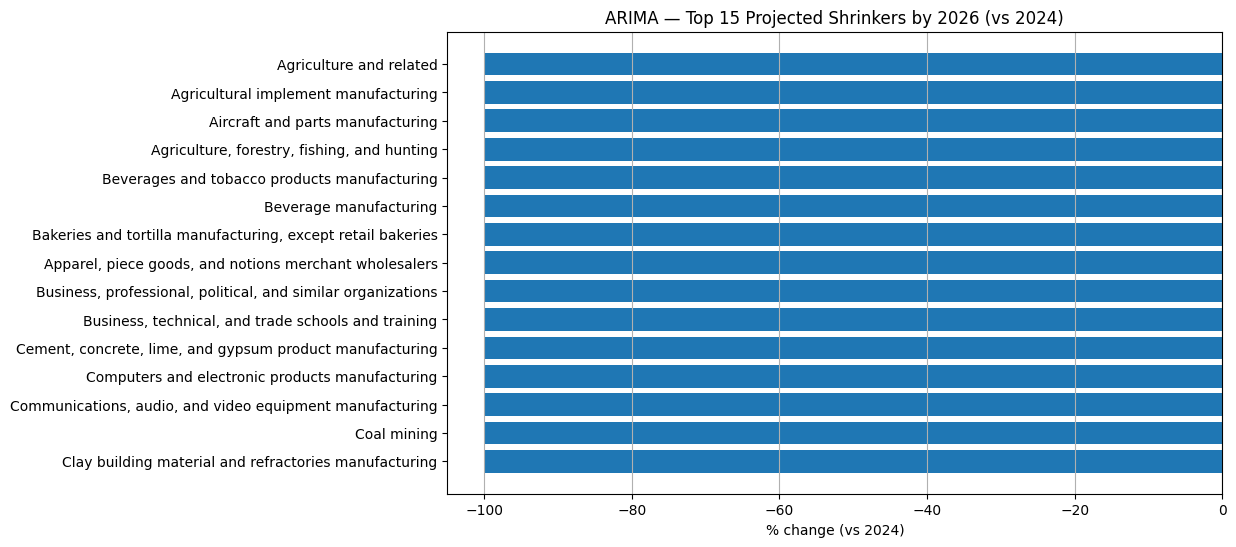

In [27]:
# 11) Forecast 2025 & 2026 for each industry (XGBoost + robust ARIMA), and show growth/shrink

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Reuse settings from above ---
# 'emp_agg' exists with columns: Year, Industry, Employed_thousands
# 'panel' exists with lag features; 'features' holds the XGB feature list you used
# XGB_AVAILABLE, XGBRegressor already imported; robust ARIMA helpers from Cell 9 exist:
#   - bounds_from_history, arima_1step_log_robust (or arima_1step_log_robust from the robust cell)
# If you added panel["post_covid"], 'features' should already include it.

# Helper: safe division (% growth)
def pct_change(base, new):
    base = float(base)
    if abs(base) < 1e-8:
        return np.nan
    return (float(new) - base) / base * 100.0

# Build a wide table of actuals by industry for convenience
wide = emp_agg.pivot(index="Industry", columns="Year", values="Employed_thousands")

# We'll require at least 2022, 2023, 2024 actuals to form 2025 features cleanly
required_years = [2022, 2023, 2024]
have_req = wide.dropna(subset=required_years, how="any").copy()

# ---- XGBoost: train per industry on rows <= 2023, then forecast 2025 & 2026 recursively ----
xgb_fc = []
if XGB_AVAILABLE:
    # To train, we use the already-prepared 'train_ready' with features and target_next_year
    # For future features, we compute them manually from the actuals/preds.
    for ind in have_req.index:
        # Train phase
        gtrain = train_ready[train_ready["Industry"] == ind].copy()
        gtrain = gtrain[(gtrain["Year"] <= 2023)].dropna(subset=features + ["target_next_year"])
        if len(gtrain) < 1:
            continue

        X_tr = gtrain[features].values
        y_tr = gtrain["target_next_year"].values

        xgb = XGBRegressor(
            n_estimators=400, max_depth=3, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, random_state=42
        )
        xgb.fit(X_tr, y_tr)

        # Build features for 2025 using the 2024 row context
        v22 = have_req.loc[ind, 2022]
        v23 = have_req.loc[ind, 2023]
        v24 = have_req.loc[ind, 2024]

        # features come from the "current row" (t = 2024) to predict t+1 (2025)
        feat_2024 = {
            "lag1": v23,
            "lag2": v22,
            "yoy_pct": (v24 - v23) / max(abs(v23), 1e-8) * 100.0,
            "two_year_change": (v24 - v22) / max(abs(v22), 1e-8) * 100.0
        }
        if "post_covid" in features:
            feat_2024["post_covid"] = 1  # 2024 is post-2020

        x_arr_2025 = np.array([[feat_2024[c] for c in features]], dtype=float)
        yhat_2025 = float(xgb.predict(x_arr_2025)[0])

        # features for 2026 come from the synthetic 2025 "row"
        # lag1 = 2024 actual; lag2 = 2023 actual; yoy & two_year_change use yhat_2025
        feat_2025 = {
            "lag1": v24,
            "lag2": v23,
            "yoy_pct": (yhat_2025 - v24) / max(abs(v24), 1e-8) * 100.0,
            "two_year_change": (yhat_2025 - v23) / max(abs(v23), 1e-8) * 100.0
        }
        if "post_covid" in features:
            feat_2025["post_covid"] = 1  # 2025 synthetic row is also post-2020

        x_arr_2026 = np.array([[feat_2025[c] for c in features]], dtype=float)
        yhat_2026 = float(xgb.predict(x_arr_2026)[0])

        xgb_fc.append({
            "Industry": ind,
            "y2024_actual": float(v24),
            "xgb_2025": max(0.0, yhat_2025),
            "xgb_2026": max(0.0, yhat_2026)
        })
else:
    print("XGBoost not available; skipping XGB forecasts.")

df_xgb_fc = pd.DataFrame(xgb_fc)

# ---- ARIMA: fit robust model on 2018..2024, forecast 2 steps (2025, 2026) ----
arima_fc = []
for ind in have_req.index:
    series = emp_agg[(emp_agg["Industry"] == ind) & (emp_agg["Year"] <= 2024)] \
                .sort_values("Year")["Employed_thousands"].values
    if len(series) >= 4:
        # First 1-step to 2025
        yhat_2025, ord1 = arima_1step_log_robust(series)
        if yhat_2025 is None:
            continue
        # Append to history and forecast 2026
        series_plus = np.append(series, yhat_2025)
        yhat_2026, ord2 = arima_1step_log_robust(series_plus)
        if yhat_2026 is None:
            continue
        arima_fc.append({
            "Industry": ind,
            "arima_2025": float(max(0.0, yhat_2025)),
            "arima_2026": float(max(0.0, yhat_2026))
        })

df_arima_fc = pd.DataFrame(arima_fc)

# ---- Combine, compute growth 2024 -> 2026 ----
summary = have_req[[2024]].rename(columns={2024:"y2024_actual"}).reset_index()
summary = summary.merge(df_xgb_fc, on=["Industry","y2024_actual"], how="left")
summary = summary.merge(df_arima_fc, on="Industry", how="left")

summary["xgb_grow_24_26_pct"]   = summary.apply(lambda r: pct_change(r["y2024_actual"], r["xgb_2026"]) if pd.notnull(r.get("xgb_2026")) else np.nan, axis=1)
summary["arima_grow_24_26_pct"] = summary.apply(lambda r: pct_change(r["y2024_actual"], r["arima_2026"]) if pd.notnull(r.get("arima_2026")) else np.nan, axis=1)

# Display a quick table
cols_show = ["Industry","y2024_actual","xgb_2025","xgb_2026","xgb_grow_24_26_pct","arima_2025","arima_2026","arima_grow_24_26_pct"]
display(summary[cols_show].head(20))

# ---- Visuals: Top growers & shrinkers by 2026 (XGB) ----
def barh_rank(df, value_col, title, topn=15, ascending=False):
    d = df[["Industry", value_col]].dropna().sort_values(value_col, ascending=ascending).head(topn)
    plt.figure(figsize=(10,6))
    plt.barh(d["Industry"], d[value_col])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("% change (vs 2024)")
    plt.grid(axis="x")
    plt.show()

# XGB
barh_rank(summary, "xgb_grow_24_26_pct", "XGB — Top 15 Projected Growers by 2026 (vs 2024)", topn=15, ascending=False)
barh_rank(summary, "xgb_grow_24_26_pct", "XGB — Top 15 Projected Shrinkers by 2026 (vs 2024)", topn=15, ascending=True)

# ARIMA (optional visuals; comment out if not useful)
barh_rank(summary, "arima_grow_24_26_pct", "ARIMA — Top 15 Projected Growers by 2026 (vs 2024)", topn=15, ascending=False)
barh_rank(summary, "arima_grow_24_26_pct", "ARIMA — Top 15 Projected Shrinkers by 2026 (vs 2024)", topn=15, ascending=True)
